In [1]:
import sys, pathlib
repo_root = pathlib.Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
# Cell 1: Import semua yang diperlukan
import json
from pathlib import Path
from shapely.geometry import shape, mapping, LineString
from shapely.ops import nearest_points
import matplotlib.pyplot as plt
from rdflib import Graph, Namespace, RDF
from rdflib.namespace import RDFS

# Import dari project kamu (sesuaikan path-nya)
import sys
sys.path.append('/path/to/your/thesis_package')  # Sesuaikan path

from thesis_package.ttl_to_json2 import (
    _local_id, _literal_float, _geom_props, _empty_instances,
    _room_type, _struct_type, _is_empty_geom,
    infer_door_geom_from_walls_or_adjacency,
    infer_window_geom_from_primary_and_hosts,
    RESPLAN, BOT, ROOM_KEYS, STRUCT_KEYS
)

In [3]:
# Cell 2: Define fungsi infer_interior_wall_FINAL
def infer_interior_wall_FINAL(
    graph,
    wall,
    adj_geom_index,
    geom_index,
    default_thickness=0.1897,
):
    """
    FINAL VERSION: Infer wall between rooms that are separated by gap.
    """
    
    def _load_shape(val):
        if val is None:
            return None
        if isinstance(val, dict):
            try:
                return shape(val)
            except:
                return None
        try:
            return shape(json.loads(str(val)))
        except:
            return None
    
    # Get adjacency and spaces
    derived = graph.value(wall, RESPLAN.derivedFrom)
    if not derived:
        return None
    
    spaceA = graph.value(derived, RESPLAN.spaceA)
    spaceB = graph.value(derived, RESPLAN.spaceB)
    
    if not spaceA or not spaceB:
        return None
    
    geomA = _load_shape(geom_index.get(spaceA))
    geomB = _load_shape(geom_index.get(spaceB))
    
    if not geomA or not geomB or geomA.is_empty or geomB.is_empty:
        return None
    
    spaceA_id = str(spaceA).split("#")[-1]
    spaceB_id = str(spaceB).split("#")[-1]
    wall_id = str(wall).split("#")[-1]
    
    # Get replaced wall info for hint
    replaced = graph.value(wall, RESPLAN.replacesWall)
    source_id = graph.value(replaced, RESPLAN.sourceId) if replaced else None
    hint = str(source_id) if source_id else wall_id
    
    # Get bounding boxes
    minxA, minyA, maxxA, maxyA = geomA.bounds
    minxB, minyB, maxxB, maxyB = geomB.bounds
    
    # Calculate overlaps
    x_overlap = min(maxxA, maxxB) - max(minxA, minxB)
    y_overlap = min(maxyA, maxyB) - max(minyA, minyB)
    
    # Calculate gaps (when rooms don't overlap)
    x_gap = max(0, max(minxA, minxB) - min(maxxA, maxxB))
    y_gap = max(0, max(minyA, minyB) - min(maxyA, maxyB))
    
    wall_line = None
    orientation = None
    
    # Heuristic: IN-01 = horizontal, IN-02 = vertical
    prefer_horizontal = 'in-01' in hint.lower() or '01' in hint
    prefer_vertical = 'in-02' in hint.lower() or '02' in hint
    
    # CASE 1: Horizontal wall
    if (y_gap > 0.05 or prefer_horizontal) and x_overlap > 0.1:
        x_start = max(minxA, minxB)
        x_end = min(maxxA, maxxB)
        
        if minyA > maxyB:
            y_wall = (minyA + maxyB) / 2
        elif minyB > maxyA:
            y_wall = (minyB + maxyA) / 2
        else:
            y_wall = (max(minyA, minyB) + min(maxyA, maxyB)) / 2
        
        wall_line = LineString([(x_start, y_wall), (x_end, y_wall)])
        orientation = "HORIZONTAL"
    
    # CASE 2: Vertical wall
    elif (x_gap > 0.05 or prefer_vertical) and y_overlap > 0.1:
        y_start = max(minyA, minyB)
        y_end = min(maxyA, maxyB)
        
        if minxA > maxxB:
            x_wall = (minxA + maxxB) / 2
        elif minxB > maxxA:
            x_wall = (minxB + maxxA) / 2
        else:
            x_wall = (max(minxA, minxB) + min(maxxA, maxxB)) / 2
        
        wall_line = LineString([(x_wall, y_start), (x_wall, y_end)])
        orientation = "VERTICAL"
    
    # CASE 3: Fallback
    else:
        p1, p2 = nearest_points(geomA, geomB)
        if p1.distance(p2) < 0.5:
            wall_line = LineString([p1, p2])
            orientation = "FALLBACK"
    
    if not wall_line or wall_line.is_empty:
        return None
    
    # Create wall polygon
    wall_poly = wall_line.buffer(
        default_thickness / 2.0,
        cap_style=3,
        join_style=2,
    )
    
    if wall_poly.is_empty or wall_poly.area < 0.001:
        return None
    
    # Log result
    print(f"   ✅ {hint} → {wall_id} ({spaceA_id}↔{spaceB_id}):")
    print(f"      Orientation: {orientation}")
    print(f"      Length: {wall_line.length:.3f}m, Area: {wall_poly.area:.4f}m²")
    
    return mapping(wall_poly)

print("✅ Fungsi infer_interior_wall_FINAL berhasil didefinisikan!")

✅ Fungsi infer_interior_wall_FINAL berhasil didefinisikan!


In [4]:
# Cell 3: Define ttl_to_plan_dict_FINAL_FIXED
def ttl_to_plan_dict_FINAL_FIXED(ttl_path):
    """Final version with proper wall inference"""
    ttl_path = Path(ttl_path)
    graph = Graph()
    graph.parse(ttl_path)

    geom_index = {s: g for s, g in graph.subject_objects(RESPLAN.geomJSON)}
    adj_geom_index = {
        a: g for a, g in graph.subject_objects(RESPLAN.geomJSON)
        if (a, RDF.type, RESPLAN.AdjacencyEdge) in graph
    }

    plan_dict = {"metadata": {}, "instances": _empty_instances()}

    # Metadata
    plan_node = next(graph.subjects(RDF.type, RESPLAN.ResPlan), None)
    if plan_node:
        label = graph.value(plan_node, RDFS.label)
        if label:
            plan_dict["metadata"]["plan_label"] = str(label)
        for pred, key in [(RESPLAN.planArea, "area"), (RESPLAN.netArea, "net_area")]:
            val = _literal_float(graph, plan_node, pred)
            if val:
                plan_dict["metadata"][key] = val
        unit_type = graph.value(plan_node, RESPLAN.unitType)
        if unit_type:
            plan_dict["metadata"]["unitType"] = str(unit_type)

    # Rooms
    for subj in graph.subjects(RDF.type, BOT.Space):
        geom_lit = graph.value(subj, RESPLAN.geomJSON)
        if not geom_lit:
            continue
        room_key = _room_type(graph, subj)
        if not room_key:
            continue
        plan_dict["instances"]["room"].setdefault(room_key, []).append({
            "id": _local_id(subj),
            "type": room_key,
            "geom": json.loads(str(geom_lit)),
            "props": _geom_props(graph, subj),
        })

    # Structural elements
    print("\n" + "="*80)
    print("INFERRING WALLS WITH FINAL SOLUTION")
    print("="*80)
    
    for struct_subj in set(graph.subjects(RDF.type, None)):
        struct_key = _struct_type(graph, struct_subj)
        if not struct_key or struct_key not in STRUCT_KEYS:
            continue

        own_geom_lit = graph.value(struct_subj, RESPLAN.geomJSON)
        geom_lit = own_geom_lit
        geom_dict = None

        # Fallbacks
        if _is_empty_geom(geom_lit):
            replaced = graph.value(struct_subj, RESPLAN.replacesWall)
            if replaced:
                geom_lit = geom_index.get(replaced)

        if _is_empty_geom(geom_lit):
            derived = graph.value(struct_subj, RESPLAN.derivedFrom)
            if derived:
                geom_lit = adj_geom_index.get(derived)

        # Infer geometries
        if struct_key == "door" and _is_empty_geom(own_geom_lit):
            geom_dict = infer_door_geom_from_walls_or_adjacency(
                graph, struct_subj, adj_geom_index, geom_index
            )

        if struct_key == "window" and _is_empty_geom(own_geom_lit):
            geom_dict = infer_window_geom_from_primary_and_hosts(
                graph, struct_subj, geom_index
            )

        # *** FINAL SOLUTION ***
        if (struct_key == "interior_wall" and 
            _is_empty_geom(own_geom_lit) and 
            _is_empty_geom(geom_lit)):
            
            geom_dict = infer_interior_wall_FINAL(
                graph, struct_subj, adj_geom_index, geom_index
            )

        # Use geometry
        if geom_dict:
            geom = geom_dict
        elif not _is_empty_geom(geom_lit):
            geom = geom_lit if isinstance(geom_lit, dict) else json.loads(str(geom_lit))
        else:
            continue

        # Normalize walls
        if struct_key in {"interior_wall", "exterior_wall"}:
            try:
                shp = shape(geom)
                if shp.geom_type in {"LineString", "MultiLineString"}:
                    shp = shp.buffer(0.06, cap_style=2, join_style=2)
                geom = mapping(shp)
            except:
                pass

        is_inferred_lit = graph.value(struct_subj, RESPLAN.isInferred)
        inferred_flag = (
            is_inferred_lit.toPython() if is_inferred_lit
            else ("infer#" in str(struct_subj))
        )

        record_id = (
            _local_id(struct_subj) if inferred_flag
            else (graph.value(struct_subj, RESPLAN.sourceId) or _local_id(struct_subj))
        )

        plan_dict["instances"]["structural"].setdefault(struct_key, []).append({
            "id": str(record_id),
            "type": struct_key,
            "geom": geom,
            "props": _geom_props(graph, struct_subj),
            "inferred": inferred_flag,
        })

    return plan_dict

print("✅ Fungsi ttl_to_plan_dict_FINAL_FIXED berhasil didefinisikan!")

✅ Fungsi ttl_to_plan_dict_FINAL_FIXED berhasil didefinisikan!


In [6]:
# Cell 4: Test konversi
ttl_file = "../output/inferred_resplan_ttl/plan_00000_walls_back.ttl"  # Ganti dengan path file kamu

# Convert
plan_dict = ttl_to_plan_dict_FINAL_FIXED(ttl_file)

# Save hasil
output_path = "output_test.json"
with open(output_path, "w") as f:
    json.dump(plan_dict, f, indent=2)

print(f"\n✅ Hasil disimpan ke: {output_path}")


INFERRING WALLS WITH FINAL SOLUTION
   ✅ IW-INF-509ed072-20ac-496a-81b7-8b6721be950a → IW-INF-509ed072-20ac-496a-81b7-8b6721be950a (BED-01↔BTH-01):
      Orientation: VERTICAL
      Length: 1.612m, Area: 0.3418m²
   ✅ IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1 → IW-INF-8296f625-3310-4f88-8d62-af1f3e46cbc1 (BED-01↔BTH-02):
      Orientation: FALLBACK
      Length: 0.126m, Area: 0.0600m²
   ✅ IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7 → IW-INF-cea3f7ac-d478-41f3-b910-67f7b0bd76e7 (BED-01↔BTH-02):
      Orientation: FALLBACK
      Length: 0.126m, Area: 0.0600m²

✅ Hasil disimpan ke: output_test.json


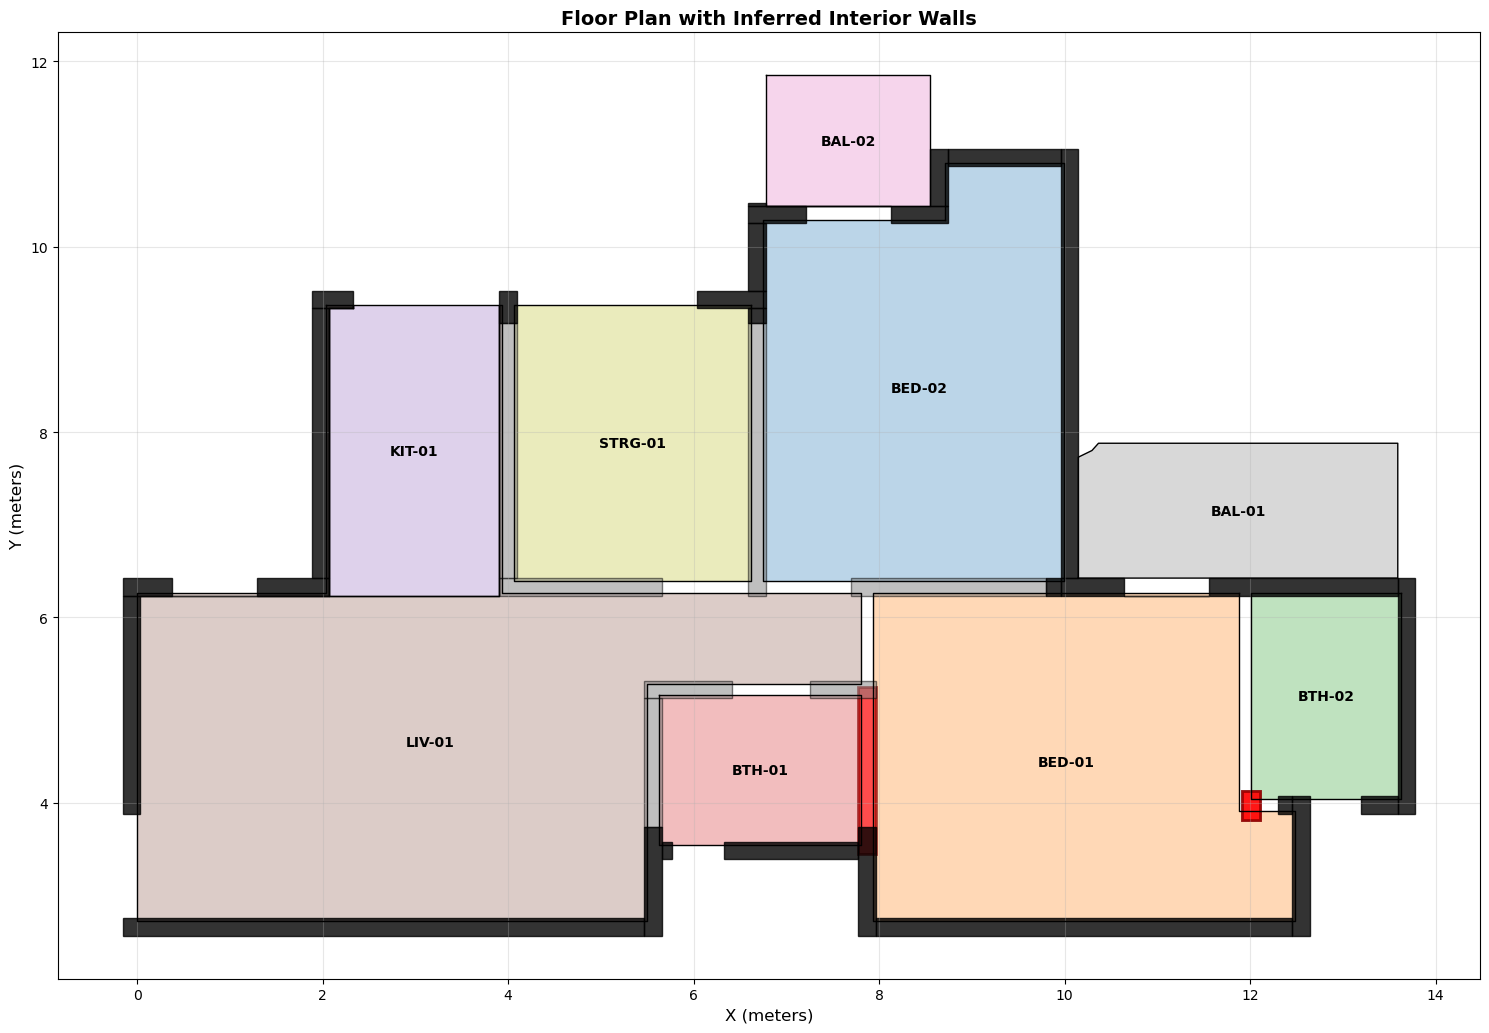

In [7]:
# Cell 5: Visualisasi
fig, ax = plt.subplots(figsize=(15, 12))

# Plot rooms
for room_type, rooms in plan_dict["instances"]["room"].items():
    for room in rooms:
        geom = shape(room["geom"])
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.3)
        ax.plot(x, y, 'k-', linewidth=1)
        
        # Label room
        centroid = geom.centroid
        ax.text(centroid.x, centroid.y, room["id"], 
                ha='center', va='center', fontsize=10, fontweight='bold')

# Plot interior walls (inferred)
if "interior_wall" in plan_dict["instances"]["structural"]:
    for wall in plan_dict["instances"]["structural"]["interior_wall"]:
        geom = shape(wall["geom"])
        x, y = geom.exterior.xy
        
        if wall.get("inferred"):
            ax.fill(x, y, color='red', alpha=0.7, edgecolor='darkred', linewidth=2)
        else:
            ax.fill(x, y, color='gray', alpha=0.5, edgecolor='black', linewidth=1)

# Plot exterior walls
if "exterior_wall" in plan_dict["instances"]["structural"]:
    for wall in plan_dict["instances"]["structural"]["exterior_wall"]:
        geom = shape(wall["geom"])
        x, y = geom.exterior.xy
        ax.fill(x, y, color='black', alpha=0.8)

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('X (meters)', fontsize=12)
ax.set_ylabel('Y (meters)', fontsize=12)
ax.set_title('Floor Plan with Inferred Interior Walls', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Cell 6: Print statistik
print("="*80)
print("STATISTIK HASIL")
print("="*80)

# Count rooms
total_rooms = sum(len(rooms) for rooms in plan_dict["instances"]["room"].values())
print(f"Total Rooms: {total_rooms}")

# Count walls
if "interior_wall" in plan_dict["instances"]["structural"]:
    int_walls = plan_dict["instances"]["structural"]["interior_wall"]
    inferred = sum(1 for w in int_walls if w.get("inferred"))
    print(f"Interior Walls: {len(int_walls)} (Inferred: {inferred})")

if "exterior_wall" in plan_dict["instances"]["structural"]:
    ext_walls = plan_dict["instances"]["structural"]["exterior_wall"]
    print(f"Exterior Walls: {len(ext_walls)}")

# Count doors & windows
for key in ["door", "window"]:
    if key in plan_dict["instances"]["structural"]:
        count = len(plan_dict["instances"]["structural"][key])
        print(f"{key.capitalize()}s: {count}")

STATISTIK HASIL
Total Rooms: 9
Interior Walls: 10 (Inferred: 3)
Exterior Walls: 28
Doors: 8
Windows: 4
